# 第076课 概率图模型的语言

先枚举联合表，再分别检查概率独立与图分离。所有参数原创，执行不下载数据。

In [1]:
from generate_data import model  # 读取人工参数。
from graph_models import *  # 读取本课小图算法。
from experiment import run  # 运行可重建的整体实验。
from IPython.display import display, Image  # 内嵌显示图片。
models = model()
chain = joint_from_bn(**models['chain'])
for row in chain:
    print(row)  # 八行完整状态，每行含联合概率。

{'state': {'A': 0, 'B': 0, 'C': 0}, 'probability': 0.43200000000000005}
{'state': {'A': 0, 'B': 0, 'C': 1}, 'probability': 0.10800000000000001}
{'state': {'A': 0, 'B': 1, 'C': 0}, 'probability': 0.005999999999999998}
{'state': {'A': 0, 'B': 1, 'C': 1}, 'probability': 0.054}
{'state': {'A': 1, 'B': 0, 'C': 0}, 'probability': 0.06399999999999999}
{'state': {'A': 1, 'B': 0, 'C': 1}, 'probability': 0.015999999999999997}
{'state': {'A': 1, 'B': 1, 'C': 0}, 'probability': 0.032}
{'state': {'A': 1, 'B': 1, 'C': 1}, 'probability': 0.2880000000000001}


## 1 条件独立不是边缘独立

下面先打印联合总和，再比较两个不同条件集合的最大独立残差。

In [2]:
print('总和:', probability(chain, {}))  # 空事件包含全部状态。
print('A,C边缘残差:', ci_residual(chain, 'A', 'C'))
print('A,C给定B残差:', ci_residual(chain, 'A', 'C', ['B']))
print('P(A=1,B=1,C=0):', probability(chain, {'A':1,'B':1,'C':0}))

总和: 1.0000000000000002
A,C边缘残差: 0.11760000000000007
A,C给定B残差: 1.1102230246251565e-16
P(A=1,B=1,C=0): 0.032


{} 0.2
{'W': 1} 0.4840731070496084
{'W': 1, 'S': 1} 0.23627684964200474
{'W': 1, 'S': 0} 0.9574468085106383


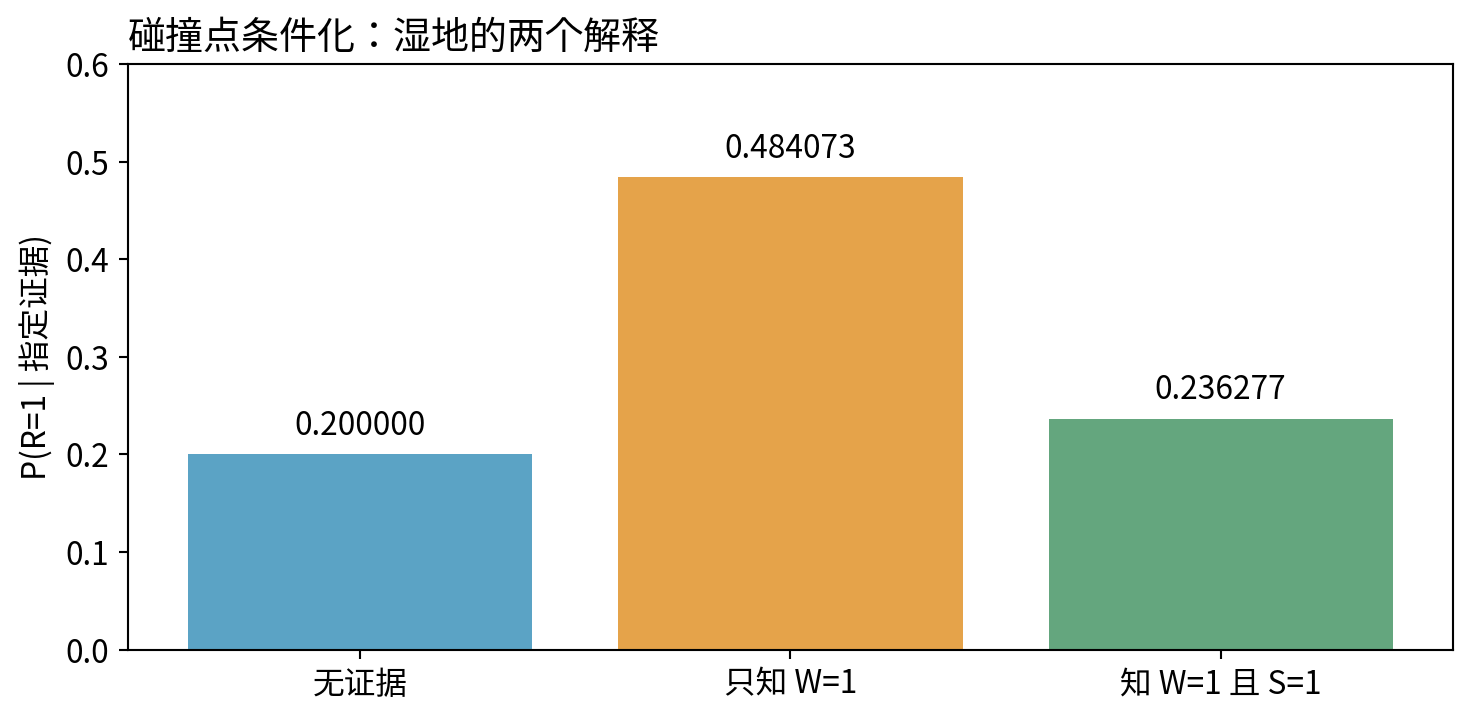

In [3]:
wet = joint_from_bn(**models['collider'])
for evidence in ({}, {'W':1}, {'W':1,'S':1}, {'W':1,'S':0}):
    print(evidence, conditional(wet, {'R':1}, evidence))  # 条件集合每次明确显示。
display(Image(filename='figures/03_explaining_away.png'))

## 2 图允许的关系与具体参数分开检验

In [4]:
nodes=['R','S','W','D']
edges=[('R','W'),('S','W'),('W','D')]
print('无证据时d分离:', d_separated(nodes,edges,'R','S'))
print('观测后代D时d分离:',d_separated(nodes,edges,'R','S',['D']))
extra=joint_from_bn(['A','B'],[('A','B')],{'A':[.4],'B':[.3,.3]})
print('有边但额外独立的残差:',ci_residual(extra,'A','B'))

无证据时d分离: True
观测后代D时d分离: False
有边但额外独立的残差: 1.3877787807814457e-17


Z: 24.0 总概率: 1.0
P(A=1,C=1|B=1): 0.5
反向链最大差: 5.551115123125783e-17
Markov等价: True


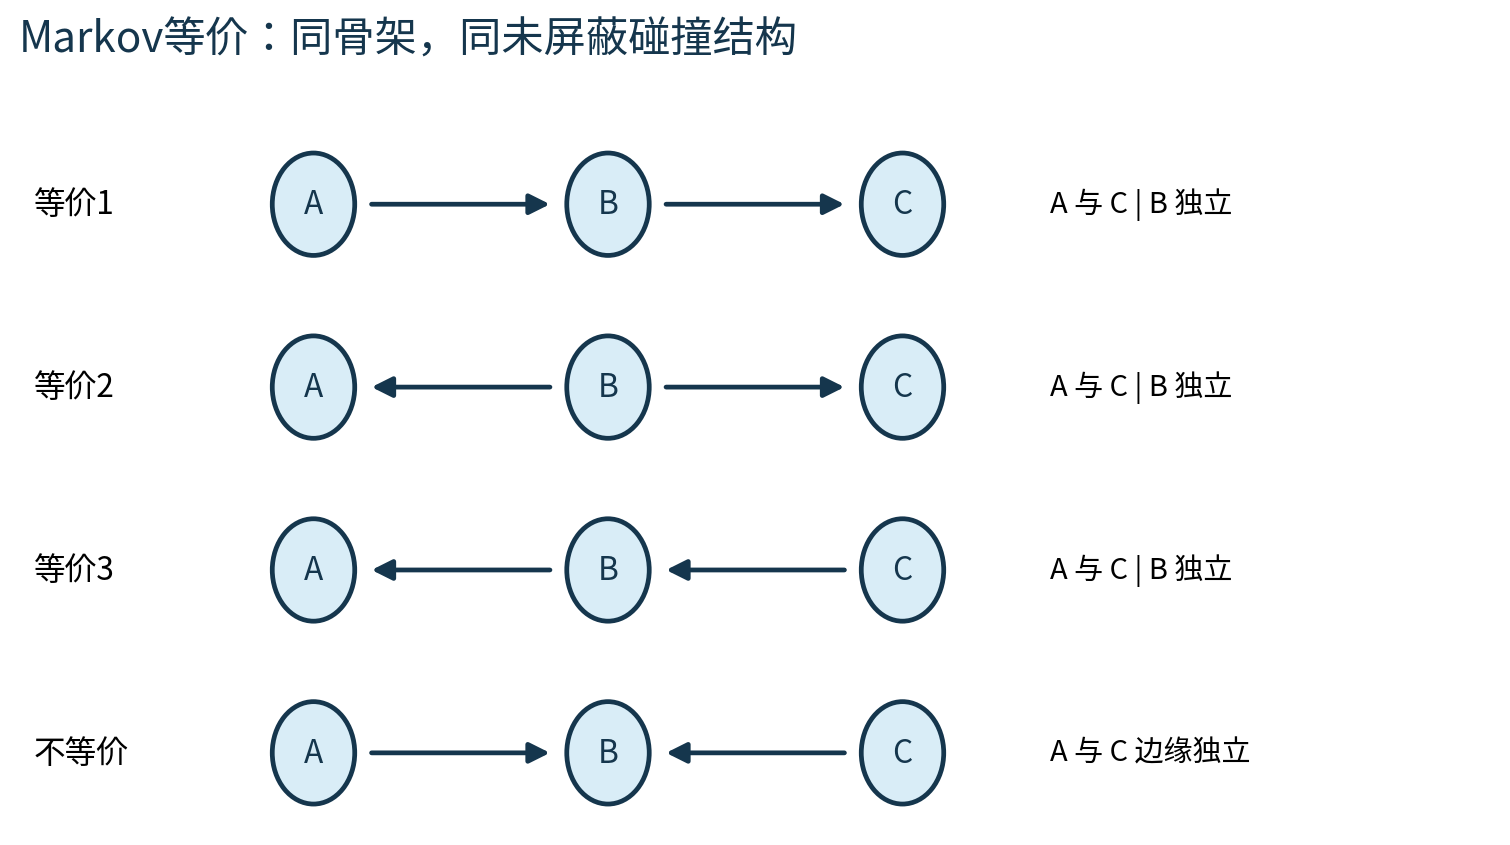

In [5]:
mrf,z=undirected_chain()
print('Z:',z,'总概率:',probability(mrf,{}))
print('P(A=1,C=1|B=1):',conditional(mrf,{'A':1,'C':1},{'B':1}))
result=run()
print('反向链最大差:',result['reverse_max_error'])
print('Markov等价:',result['markov_equivalent'])
display(Image(filename='figures/04_equivalence.png'))

In [6]:
import unittest  # 显式测试不受python -O去除assert影响。
from test_experiment import Checks
tests=unittest.TextTestRunner(verbosity=1).run(unittest.defaultTestLoader.loadTestsFromTestCase(Checks))
if not tests.wasSuccessful():
    raise RuntimeError('unit tests failed')
print('本Notebook所有计算和测试完成。')

.

.

.

.

.

.

----------------------------------------------------------------------
Ran 6 tests in 0.005s

OK


本Notebook所有计算和测试完成。


## 复盘

数值独立是固定概率表的性质；d分离是因子化分布家族的结构保证。测试和枚举不能自动转化为现实因果结论。